In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Step 1: Read input data into a dataframe

In [140]:
from pathlib import Path

# https://www.kaggle.com/datasets/taeefnajib/used-car-price-prediction-dataset

dataset_path = Path(Path.cwd() / "datasets" / "used_cars.csv")
used_cars = pd.read_csv(dataset_path)

used_cars.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [141]:
used_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


## Step 2: Pre-process the data and extract the features that can be given as an input to the algorithm

### Step 2.1: Remove dupliacates

In [142]:
duplicate_count = used_cars.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
used_cars.drop_duplicates(inplace=True)

Number of duplicate rows: 0


### Step 2.2: Cleanse integer columns by removing non-integer values

In [143]:
# mileage and price are the two columns to be cleansed

float_columns = ['milage', 'price']
for col in float_columns:
    # 1. Replace everything that isn't a digit or a dot with an empty string
    used_cars[col] = used_cars[col].str.replace(r'[^\d.]', '', regex=True)
    # 2. Convert to numeric (float is safest for handling NaNs)
    used_cars[col] = pd.to_numeric(used_cars[col], errors='coerce').astype(float)


used_cars.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598.0
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500.0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999.0


In [144]:
used_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         4009 non-null   object 
 1   model         4009 non-null   object 
 2   model_year    4009 non-null   int64  
 3   milage        4009 non-null   float64
 4   fuel_type     3839 non-null   object 
 5   engine        4009 non-null   object 
 6   transmission  4009 non-null   object 
 7   ext_col       4009 non-null   object 
 8   int_col       4009 non-null   object 
 9   accident      3896 non-null   object 
 10  clean_title   3413 non-null   object 
 11  price         4009 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 376.0+ KB


### Step 2.3: Check for NULLs

In [145]:
used_cars.isnull()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
4004,False,False,False,False,False,False,False,False,False,False,False,False
4005,False,False,False,False,False,False,False,False,False,False,False,False
4006,False,False,False,False,True,False,False,False,False,False,True,False
4007,False,False,False,False,False,False,False,False,False,False,False,False


In [146]:
used_cars.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [147]:
# Viewing as a Percentage
used_cars.isnull().mean() * 100

brand            0.000000
model            0.000000
model_year       0.000000
milage           0.000000
fuel_type        4.240459
engine           0.000000
transmission     0.000000
ext_col          0.000000
int_col          0.000000
accident         2.818658
clean_title     14.866550
price            0.000000
dtype: float64

### Step 2.4: Check the count of unique values for all Categorical columns

In [148]:
categorical_columns = used_cars.select_dtypes(include=['object']).columns
print(type(categorical_columns))
categorical_columns

<class 'pandas.core.indexes.base.Index'>


Index(['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col',
       'int_col', 'accident', 'clean_title'],
      dtype='object')

#### Step 2.4.1: Checking the "Cardinality" -> number of unique values

In [149]:
used_cars[categorical_columns].nunique().sort_values(ascending=False)

model           1898
engine          1146
ext_col          319
int_col          156
transmission      62
brand             57
fuel_type          7
accident           2
clean_title        1
dtype: int64

#### Step 2.4.2 Check the unique values and respective counts

In [150]:
for col in categorical_columns:
    print(f"Column: {col}")
    print(used_cars[col].value_counts())
    print("\n")

Column: brand
brand
Ford             386
BMW              375
Mercedes-Benz    315
Chevrolet        292
Porsche          201
Audi             200
Toyota           199
Lexus            163
Jeep             143
Land             130
Nissan           116
Cadillac         107
GMC               91
RAM               91
Dodge             90
Tesla             87
Kia               76
Hyundai           72
Mazda             64
Acura             64
Subaru            64
Honda             63
Volkswagen        59
INFINITI          59
Lincoln           52
Jaguar            47
Volvo             38
Maserati          34
Bentley           33
MINI              33
Buick             30
Chrysler          28
Lamborghini       26
Mitsubishi        20
Genesis           20
Alfa              19
Rivian            17
Hummer            16
Pontiac           15
Ferrari           12
Rolls-Royce       11
Aston              9
McLaren            6
Scion              6
FIAT               5
Saturn             5
Lotus         

In [151]:
import re

# Function to parse the engine string
def extract_engine_features(df):
    
    # 1. Extract Horsepower (HP)
    # Looks for a number (int or float) followed immediately by 'HP'
    df['horsepower'] = df['engine'].str.extract(r'(\d+\.?\d*)HP').astype(float)
    
    # 2. Extract Displacement (Liters)
    # Looks for a number followed immediately by 'L'
    df['engine_displacement'] = df['engine'].str.extract(r'(\d+\.?\d*)L').astype(float)
    
    # 3. Extract Cylinders
    # This is a two-step process to catch different formats
    
    # Step A: Look for explicit "6 Cylinder" pattern
    df['cylinders'] = df['engine'].str.extract(r'(\d+) Cylinder').astype(float)
    
    # Step B (Backup): Look for "V6", "V8", "I4" patterns if Step A failed
    # We find 'V' or 'I' followed by a digit
    mask_null = df['cylinders'].isnull()
    df.loc[mask_null, 'cylinders'] = df.loc[mask_null, 'engine'].str.extract(r'[V|I|H](\d+)').astype(float)

    return df

# Apply the function
used_cars = extract_engine_features(used_cars)

# Check the results
print(used_cars[['engine', 'horsepower', 'engine_displacement', 'cylinders']].head())

                                              engine  horsepower  \
0  300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...       300.0   
1                               3.8L V6 24V GDI DOHC         NaN   
2                                     3.5 Liter DOHC         NaN   
3  354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...       354.0   
4                         2.0L I4 16V GDI DOHC Turbo         NaN   

   engine_displacement  cylinders  
0                  3.7        6.0  
1                  3.8        NaN  
2                  NaN        NaN  
3                  3.5        6.0  
4                  2.0        NaN  


## For learning the regression algorithm and not to lost in the feature engineering - simplifying the dataset by removing few complex columns

In [152]:
# Create the mapping dictionary
accident_map = {
    'None reported': 0,
    'At least 1 accident or damage reported': 1
}

In [153]:
# 1. Select only the "Easy" columns
# (We assume 'horsepower' exists if you ran the previous step. If not, remove it from this list)
simple_cols = ['model_year', 'milage', 'accident', 'price']

# Create a simplified dataframe
df_simple = used_cars[simple_cols].copy()

# 2. Apply the map
# .map() is faster and cleaner than replace() for this specific task
df_simple['accident'] = df_simple['accident'].map(accident_map)


# 3. Derive age out of model_year
import datetime

# Determine the current year dynamically
current_year = datetime.datetime.now().year
# Create the 'age' column
df_simple['age'] = current_year - df_simple['model_year']
# Drop the original 'model_year' column
df_simple.drop(columns=['model_year'], inplace=True)

# 4. The "Nuclear Option" for Missing Values
# Since we want speed, we just drop any row with a blank value.
# (We lose some data, but we gain speed)
df_simple.dropna(inplace=True)


# 3. Convert Categorical Columns to Numbers (One-Hot Encoding)
# This turns "fuel_type" into "fuel_type_Gas", "fuel_type_Diesel", etc.
# drop_first=True prevents "multicollinearity" (a common issue in regression)
# df_final = pd.get_dummies(df_simple, columns=['accident'], drop_first=True)

# 4. Preview your ready-to-train data
print("Final Data Shape:", df_simple.shape)
print(df_simple.head())

Final Data Shape: (3896, 4)
    milage  accident    price  age
0  51000.0       1.0  10300.0   13
1  34742.0       1.0  38005.0    5
2  22372.0       0.0  54598.0    4
3  88900.0       0.0  15500.0   11
4   9835.0       0.0  34999.0    5


We will use an 80/20 split, which is standard for a dataset of this size (~4,000 rows). This means 80% of the data is used to teach the model, and 20% is hidden away to test it later.

In [154]:
from sklearn.model_selection import train_test_split

# 1. Separate Features (X) and Target (y)
# X contains the inputs: age, milage, accident
X = df_simple.drop(columns=['price']) 

# y contains the output we want to predict: price
y = df_simple['price']

# 2. Perform the Split
# random_state=42 ensures you get the exact same split every time you run the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Verify the Split
print(f"Training Set Shape: {X_train.shape} (Rows, Columns)")
print(f"Testing Set Shape:  {X_test.shape} (Rows, Columns)")

Training Set Shape: (3116, 3) (Rows, Columns)
Testing Set Shape:  (780, 3) (Rows, Columns)


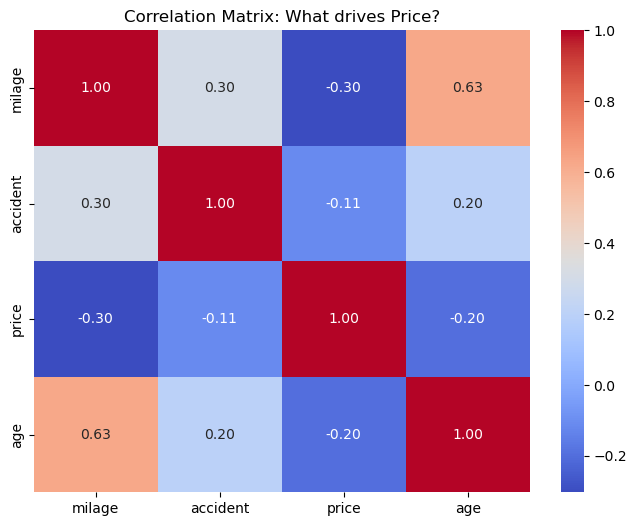

In [155]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix
corr = df_simple.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: What drives Price?")
plt.show()

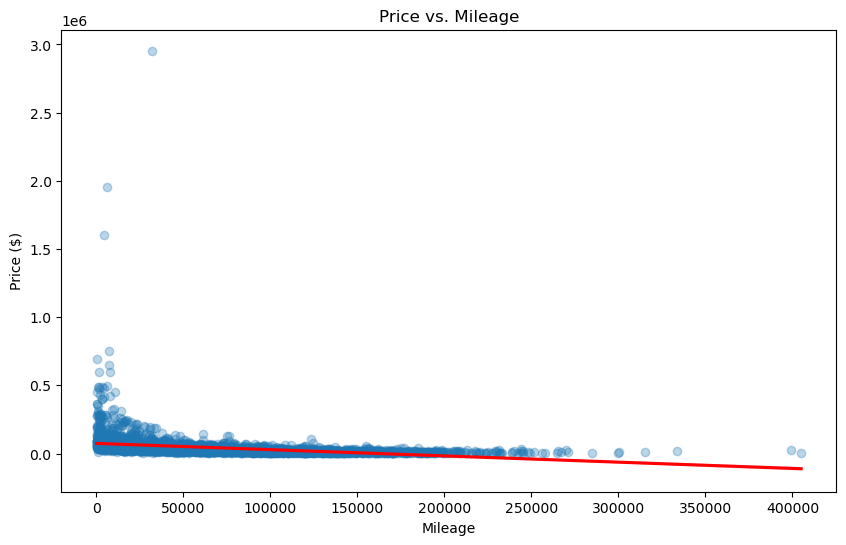

In [158]:
plt.figure(figsize=(10, 6))

# Scatter plot with a regression line (reg=True)
sns.regplot(x='milage', y='price', data=df_simple, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title("Price vs. Mileage")
plt.xlabel("Mileage")
plt.ylabel("Price ($)")
plt.show()

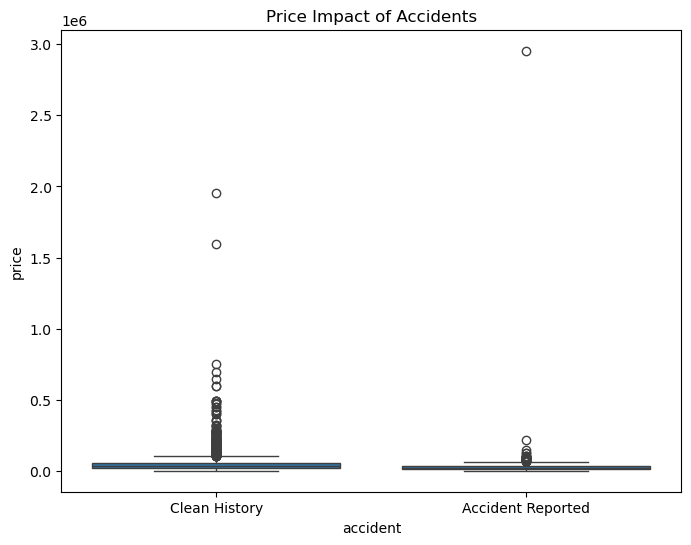

In [159]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='accident', y='price', data=df_simple)

plt.xticks([0, 1], ['Clean History', 'Accident Reported'])
plt.title("Price Impact of Accidents")
plt.show()